In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\Thinkpad\Desktop\My Learnings\GenAI\Simplilearn\DS\sales_analysis_project\AusApparalSales4thQrt2020.csv")

In [3]:
df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


In [5]:
df.shape

(7560, 6)

In [6]:
df.describe()

,Unit,Sales
count,7560.000000,7560.000000
mean,18.005423,45013.558201
std,12.901403,32253.506944
min,2.000000,5000.000000
25%,8.000000,20000.000000
50%,14.000000,35000.000000
75%,26.000000,65000.000000
max,65.000000,162500.000000


### 1) Data Wrangling

In [7]:
# Task 1a

print("Missing values in each column: ")
print(df.isna().sum())

print("\nNon-missing values in each column: ")
print(df.notna().sum())

Missing values in each column: 
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

Non-missing values in each column: 
Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64


In [8]:
# Task 1b

print("dropping null values: ")
print("\n")
df.dropna(how="all", inplace=True)
df.info()

print("\n")

print("replacing null values with mean: ")
print("\n")
df["Sales"] = df["Sales"].fillna(df["Sales"].mean())
df["Sales"]


dropping null values: 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


replacing null values with mean: 




0       20000
1       20000
2       10000
3       37500
4        7500
        ...  
7555    35000
7556    37500
7557    37500
7558    27500
7559    32500
Name: Sales, Length: 7560, dtype: int64

In [9]:
#Task 1c

#Normaliztion
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[["Sales", "Unit"]] = scaler.fit_transform(df[["Sales", "Unit"]])
df[["Sales", "Unit"]]

,Sales,Unit
0,0.095238,0.095238
1,0.095238,0.095238
2,0.031746,0.031746
3,0.206349,0.206349
4,0.015873,0.015873
...,...,...
7555,0.190476,0.190476
7556,0.206349,0.206349
7557,0.206349,0.206349
7558,0.142857,0.142857


In [10]:
#Task 1d

state_sales = df.groupby("State")["Sales"].sum().reset_index()

state_sales.sort_values(by="Sales", ascending=False)

,State,Sales
5,VIC,635.968254
0,NSW,441.714286
3,SA,339.412698
2,QLD,177.888889
4,TAS,110.222222
1,NT,109.079365
6,WA,106.365079


### 2) Data Analytics

In [11]:
#Task 2a
# Perform descriptive statistical analysis on the data (Sales and Unit columns)

print(df[["Sales", "Unit"]].describe())

print(df[["Sales", "Unit"]].mode())

             Sales         Unit
count  7560.000000  7560.000000
mean      0.254054     0.254054
std       0.204784     0.204784
min       0.000000     0.000000
25%       0.095238     0.095238
50%       0.190476     0.190476
75%       0.380952     0.380952
max       1.000000     1.000000
      Sales      Unit
0  0.111111  0.111111


In [12]:
#Task 2b
#Determine which group is generating the highest sales, and which group is generating the lowest sales.

tp_sales_group = df.groupby("Group")["Sales"].sum().idxmax()

low_sales_group = df.groupby("Group")["Sales"].sum().idxmin()

print(f"Highest sales: {tp_sales_group}")
print(f"\nLowest sales: {low_sales_group}")

Highest sales:  Men

Lowest sales:  Seniors


In [13]:
#Task 2c
#same as Task 2b

In [14]:
#Task 2d
#Generate weekly, monthly and quarterly reports for the analysis made.

df["Date"] = pd.to_datetime(df["Date"])

df["Week"] = df["Date"].dt.isocalendar().week
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter

In [15]:
#weekly sales report

weekly_sales = df.groupby("Week")["Sales"].sum().reset_index()
print(f"Weekly Sales: \n\n{weekly_sales}")

#Monthly sales report

monthly_sales = df.groupby("Month")["Sales"].sum().reset_index()
print(f"\nMonthly Sales: \n\n{monthly_sales}")

#weekly sales report

quarterly_sales = df.groupby("Quarter")["Sales"].sum().reset_index()
print(f"\nQuarterly Sales: \n\n{quarterly_sales}")

Weekly Sales: 

    Week       Sales
0     40   84.857143
1     41  152.777778
2     42  150.476190
3     43  151.587302
4     44  122.460317
5     45  113.809524
6     46  115.761905
7     47  115.380952
8     48  117.698413
9     49  169.412698
10    50  181.492063
11    51  182.317460
12    52  183.047619
13    53   79.571429

Monthly Sales: 

   Month       Sales
0     10  645.650794
1     11  495.761905
2     12  779.238095

Quarterly Sales: 

   Quarter        Sales
0        4  1920.650794


### Data Vizualization

In [16]:
#Task 3a
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style="whitegrid")

%matplotlib inline

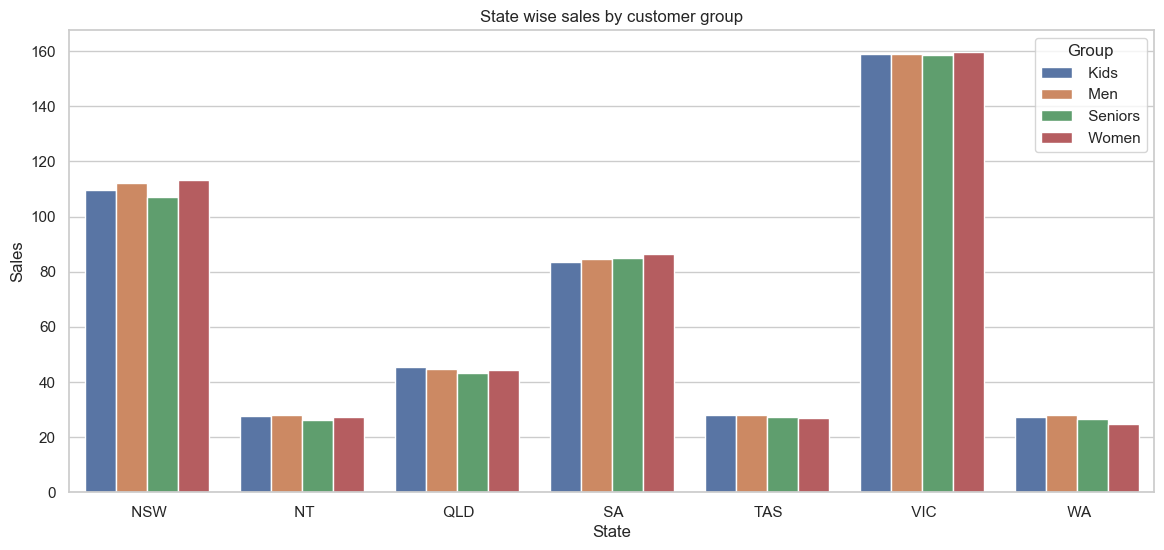

In [17]:
#Task 3a-1
# State-wise sales analysis for different groups (kids, women, men, and seniors) 

state_group_sales = df.groupby(["State", "Group"]) ["Sales"].sum().reset_index()

plt.figure(figsize=(14,6))
sns.barplot(data=state_group_sales, x="State", y="Sales", hue="Group")
plt.title("State wise sales by customer group")

plt.show()

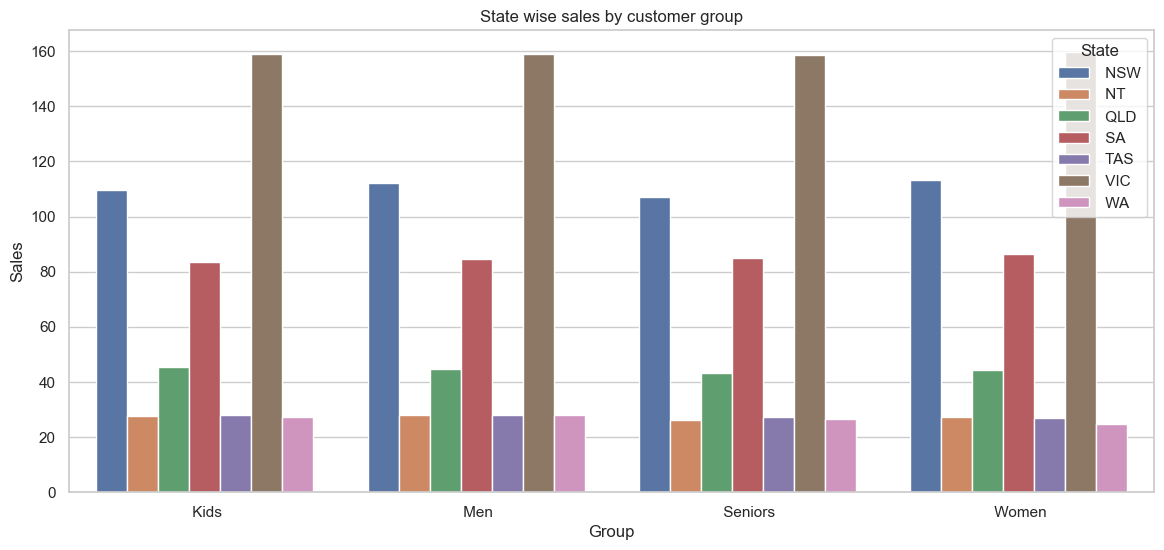

In [18]:
# Task 3a-2
# Group-wise sales analysis (kids, women, men, and seniors) across different states.

state_group_sales = df.groupby(["Group", "State"]) ["Sales"].sum().reset_index()

plt.figure(figsize=(14,6))
sns.barplot(data=state_group_sales, x="Group", y="Sales", hue="State")
plt.title("State wise sales by customer group")

plt.show()

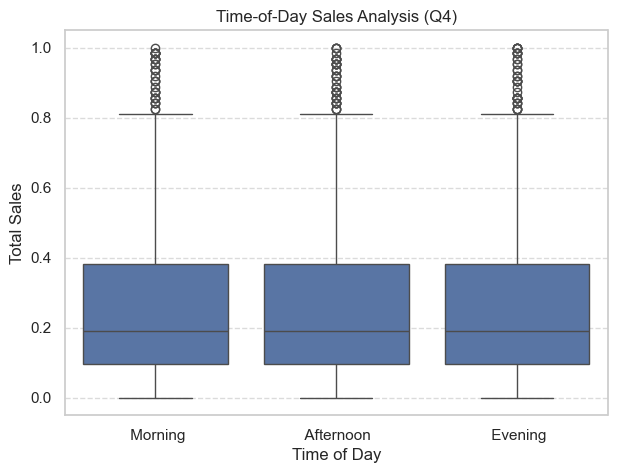

In [19]:
#Task 3a-3
#Time-of-the-day analysis: during which time of the day are sales the highest, and during which time are sales the lowest? 
#[This helps S&M teams design programs for increasing sales such as hyper-personalization and Next Best Offers].

plt.figure(figsize=(7,5))

sns.boxplot(data=df, x="Time", y="Sales")
plt.title("Time-of-Day Sales Analysis (Q4)")
plt.xlabel("Time of Day")
plt.ylabel("Total Sales")

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

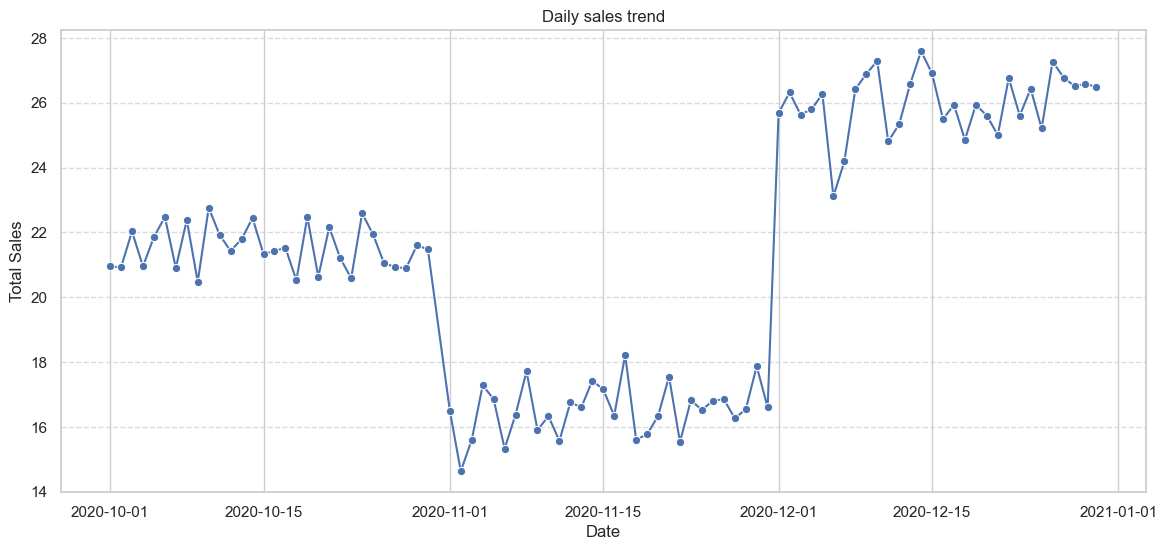

In [24]:
# Task 3b

daily_sales_trend = df.groupby("Date") ["Sales"].sum().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(data=daily_sales_trend, x="Date", y="Sales", marker="o")

plt.title("Daily sales trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

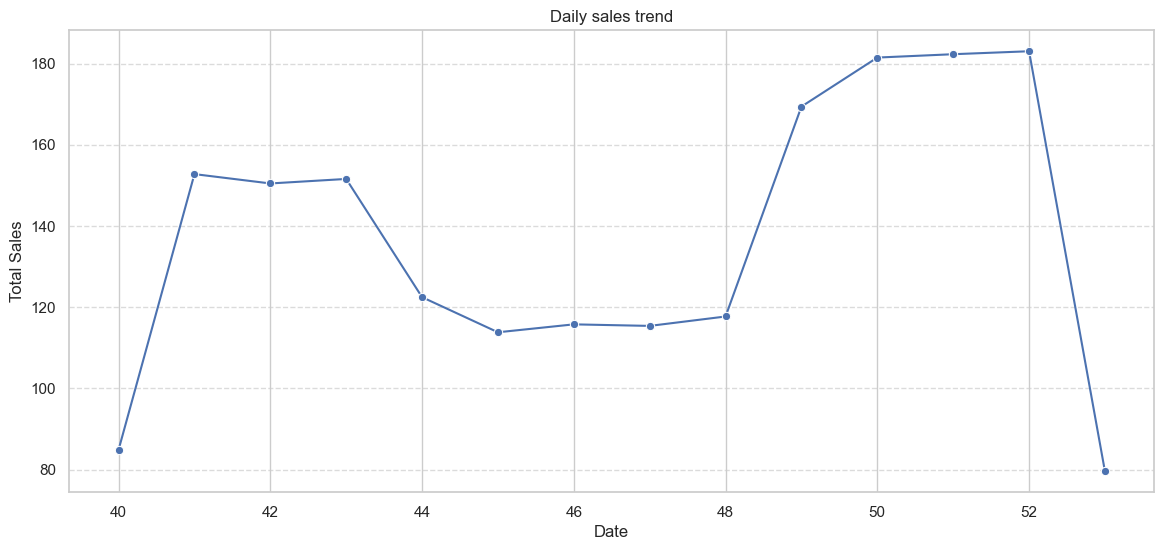

In [32]:
# Task 3b
#weekly sales trend

plt.figure(figsize=(14,6))
sns.lineplot(data=weekly_sales, x="Week", y="Sales", marker="o", estimator=None)

plt.title("Weekly sales trend")
plt.xlabel("Week")
plt.ylabel("Total Sales")

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

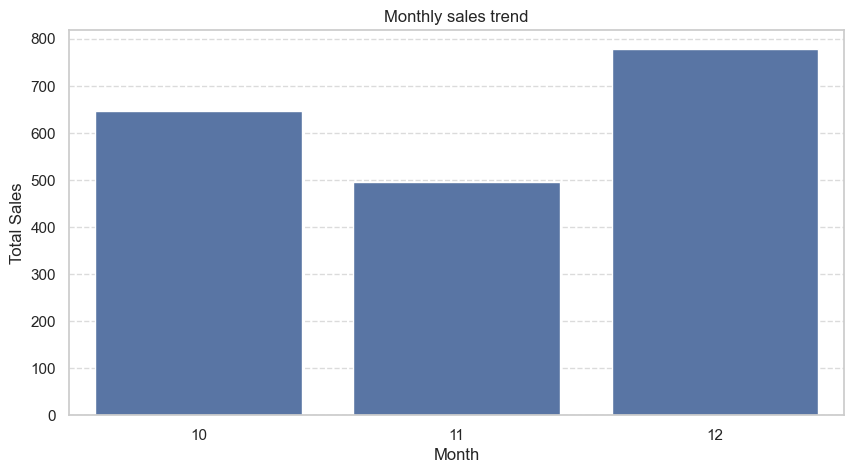

In [42]:
# Task 3b
#monthly sales trend

plt.figure(figsize=(10,5))
sns.barplot(data=monthly_sales, x="Month", y="Sales")

plt.title("Monthly sales trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

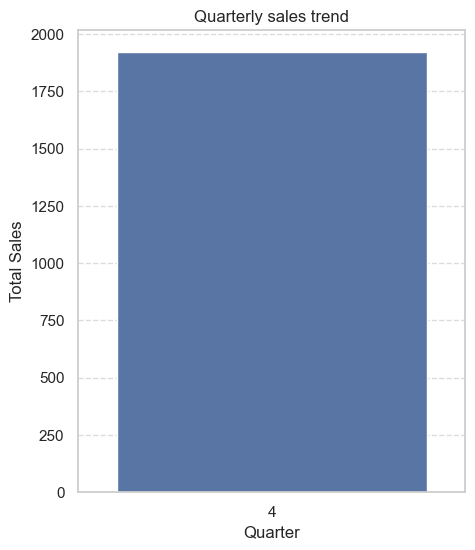

In [46]:
# Task 3b
# Quarterly sales trend

plt.figure(figsize=(5,6))
sns.barplot(data=quarterly_sales, x="Quarter", y="Sales")

plt.title("Quarterly sales trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

#Task 3c 

**Recommendation – Visualization Package**

Reason:

**Seaborn** is built on top of Matplotlib and provides:
- Clean and professional plots with minimal code.
- Better support for statistical visualizations (bar plots, box plots, line plots).
- Readable styles and built-in themes, making the charts clear for business dashboards.

In [49]:
report = """
Sales Analysis Report (Q4)

1. State-wise Sales Analysis:
- Top states: VIC
- Lowest performing states: WA

2. Sales Distribution by Group:
- Highest sales category: Men
- Lowest sales category: Seniors

3. Sales Trends:
- Daily: Sales fluctuations throughout Q4
- Weekly: Identified high and low sales weeks
- Monthly: Sales trends for each month in Q4
- Quarterly: Overall Q4 sales comparison by state

Recommendations:
- Optimize inventory for peak hours
- Improve marketing strategies in low-sales states
- Leverage Q4 sales trends for better promotions
"""
print(report)


Sales Analysis Report (Q4)

1. State-wise Sales Analysis:
- Top states: VIC
- Lowest performing states: WA

2. Sales Distribution by Group:
- Highest sales category: Men
- Lowest sales category: Seniors

3. Sales Trends:
- Daily: Sales fluctuations throughout Q4
- Weekly: Identified high and low sales weeks
- Monthly: Sales trends for each month in Q4
- Quarterly: Overall Q4 sales comparison by state

Recommendations:
- Optimize inventory for peak hours
- Improve marketing strategies in low-sales states
- Leverage Q4 sales trends for better promotions

